<a href="https://colab.research.google.com/github/HafizRizqi/MachineLearning_2026/blob/main/KUIS1_244107020154_Hafiz_Rizqi_Hernanda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [34]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [57]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [58]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [59]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [60]:
# Data Size
df.shape

(48842, 15)

In [61]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [62]:
# Jawab Soal 1

# Inspeksi profile data
print("Informasi Dataset:")
df.info()

print("\nUkuran Dataset:")
print(df.shape)

print("\nJumlah Missing Value Setiap Variabel:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\nTotal Missing Value:")
print(df.isnull().sum().sum())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

Ukuran Dataset:
(48842, 15)

Jumlah Missing Value Setiap Variabel:
workcl

## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [63]:
# Jawab Soal 2

# Menentukan fitur yang memiliki missing value
kolom_missing = ['workclass', 'occupation', 'native-country']

# Melakukan imputation menggunakan nilai modus
for kolom in kolom_missing:
    df[kolom] = df[kolom].fillna(df[kolom].mode()[0])

# Mengecek kembali missing value
print("Jumlah Missing Value Setelah Imputation:")
print(df.isnull().sum())

print("\nTotal Missing Value Setelah Imputation:")
print(df.isnull().sum().sum())

Jumlah Missing Value Setelah Imputation:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Total Missing Value Setelah Imputation:
0


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [64]:
# Jawab Soal 3

# Menampilkan jumlah kategori unik pada setiap fitur kualitatif
kolom_kualitatif = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'income'
]

for kolom in kolom_kualitatif:
    print(f"\n=== {kolom} ===")
    print(df[kolom].value_counts())


=== workclass ===
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

=== education ===
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

=== marital-status ===
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

=== occupation ===
oc

In [65]:
# Mengganti value '?' pada fitur kualitatif menjadi 'Others'
kolom_others = ['workclass', 'occupation', 'native-country']

for kolom in kolom_others:
    df[kolom] = df[kolom].replace('?', 'Others')

# Menyesuaikan penulisan pada variabel income
df['income'] = df['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

# Mengecek kembali nilai unik setiap fitur kualitatif
for kolom in kolom_kualitatif:
    print(f"\n=== {kolom} ===")
    print(df[kolom].value_counts())


=== workclass ===
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Others               1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

=== education ===
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

=== marital-status ===
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

=== occupation ===
oc

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

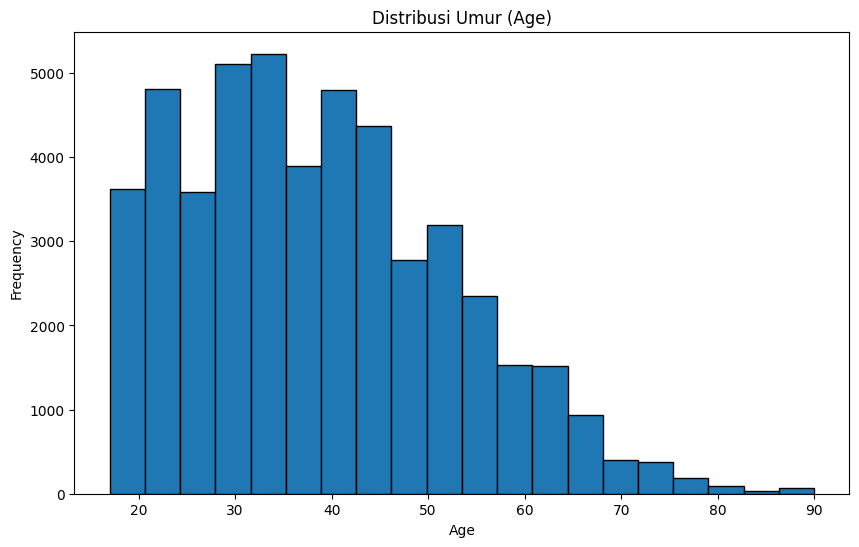

In [66]:
# Jawab 1.1 - Histogram

plt.figure(figsize=(10, 6))

plt.hist(df['age'], bins=20, edgecolor='black')

plt.title('Distribusi Umur (Age)')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

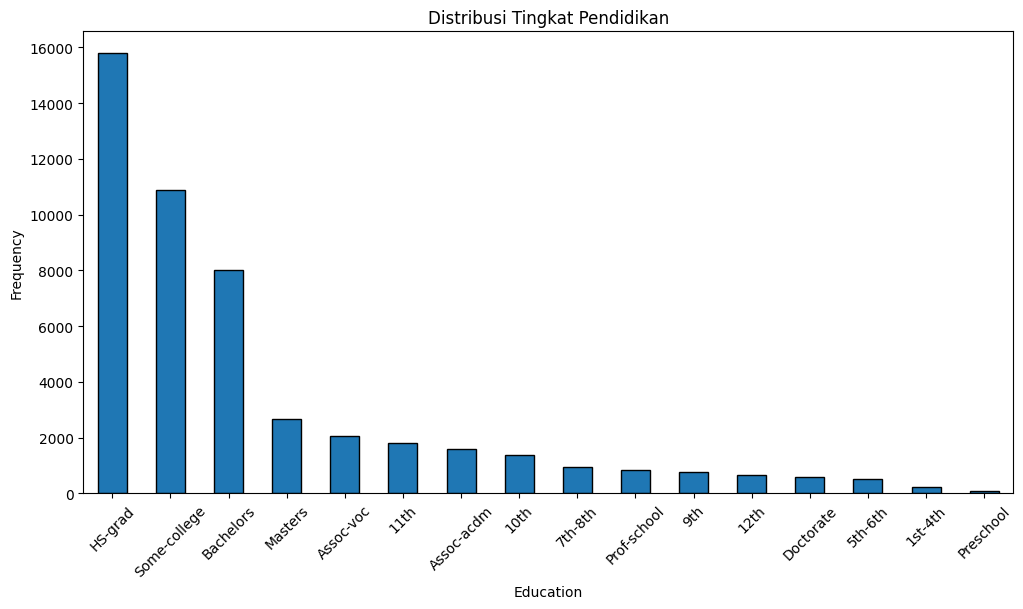

In [67]:
# Jawab 1.2 - Barchart

education_counts = df['education'].value_counts()

plt.figure(figsize=(12, 6))

education_counts.plot(kind='bar', edgecolor='black')

plt.title('Distribusi Tingkat Pendidikan')
plt.xlabel('Education')
plt.ylabel('Frequency')

plt.xticks(rotation=45)
plt.show()

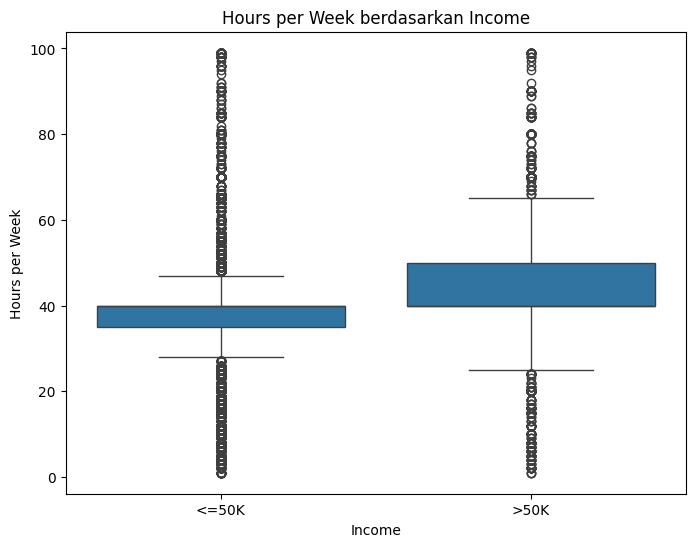

In [68]:
# Jawab 1.3 - Boxplot

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='income',
    y='hours-per-week'
)

plt.title('Hours per Week berdasarkan Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')

plt.show()

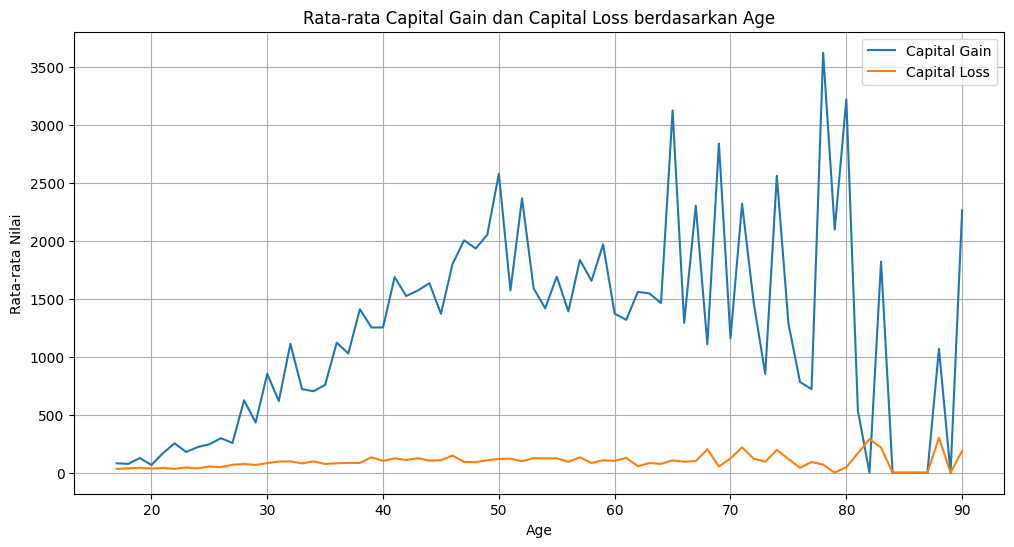

In [69]:
# Jawab 1.4 - Lineplot

age_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    age_capital.index,
    age_capital['capital-gain'],
    label='Capital Gain'
)

plt.plot(
    age_capital.index,
    age_capital['capital-loss'],
    label='Capital Loss'
)

plt.title('Rata-rata Capital Gain dan Capital Loss berdasarkan Age')
plt.xlabel('Age')
plt.ylabel('Rata-rata Nilai')

plt.legend()
plt.grid(True)

plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [ ]:
# Jawaban:
'''
  1. Distribusi data age menunjukkan bahwa jumlah data lebih banyak berada
  pada rentang usia dewasa, terutama sekitar usia 20 hingga 50 tahun.
  Setelah usia tersebut, jumlah data cenderung semakin menurun.
  Distribusi age tidak merata dan cenderung memiliki ekor ke arah usia yang lebih tua.

  2. Jika terdapat data yang hilang pada variabel age, strategi yang dapat
  digunakan adalah imputasi menggunakan median.
  Median dipilih karena age merupakan variabel numerik dan distribusinya
  tidak sepenuhnya simetris. Median lebih tahan terhadap pengaruh outlier
  dibandingkan mean sehingga dapat mempertahankan karakteristik distribusi data.

  3. Jumlah outlier pada variabel 'hours-per-week' dapat diketahui dari boxplot
dengan melihat data yang berada di luar batas whisker untuk masing-masing
kategori income. Kategori income dengan jumlah titik di luar whisker paling
banyak merupakan kategori yang memiliki outlier terbanyak.
'''

'\n  Bisa dengan multiple comment\n  seperti ini\n'

In [70]:
# Jawaban no.3 :

for income_category in df['income'].unique():

    data = df[df['income'] == income_category]['hours-per-week']

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data < lower_bound) |
        (data > upper_bound)
    ]

    print(f"Income: {income_category}")
    print(f"Jumlah outlier: {len(outliers)}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print()

    # Menghitung jumlah outlier setiap kategori income

outlier_counts = {}

for income_category in df['income'].unique():

    data = df[df['income'] == income_category]['hours-per-week']

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = ((data < lower_bound) | (data > upper_bound)).sum()

    outlier_counts[income_category] = count

print(outlier_counts)

most_outlier = max(outlier_counts, key=outlier_counts.get)

print("\nKategori dengan outlier terbanyak:", most_outlier)
print("Jumlah:", outlier_counts[most_outlier])

Income: <=50K
Jumlah outlier: 11706
Lower Bound: 27.5
Upper Bound: 47.5

Income: >50K
Jumlah outlier: 781
Lower Bound: 25.0
Upper Bound: 65.0

{'<=50K': np.int64(11706), '>50K': np.int64(781)}

Kategori dengan outlier terbanyak: <=50K
Jumlah: 11706


# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [71]:
# Jawab Soal 1

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encoding variabel Sex
df['sex'] = le.fit_transform(df['sex'])

# Encoding variabel Income sebagai target
df['income'] = le.fit_transform(df['income'])

# Menentukan Income sebagai variabel target
X = df.drop('income', axis=1)
y = df['income']

df[['sex', 'income']].head()

,sex,income
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

Matriks Korelasi:


,age,education-num,hours-per-week,capital-gain,capital-loss,income
age,1.000000,0.030940,0.071558,0.077229,0.056944,0.230369
education-num,0.030940,1.000000,0.143689,0.125146,0.080972,0.332613
hours-per-week,0.071558,0.143689,1.000000,0.082157,0.054467,0.227687
capital-gain,0.077229,0.125146,0.082157,1.000000,-0.031441,0.223013
capital-loss,0.056944,0.080972,0.054467,-0.031441,1.000000,0.147554
income,0.230369,0.332613,0.227687,0.223013,0.147554,1.000000


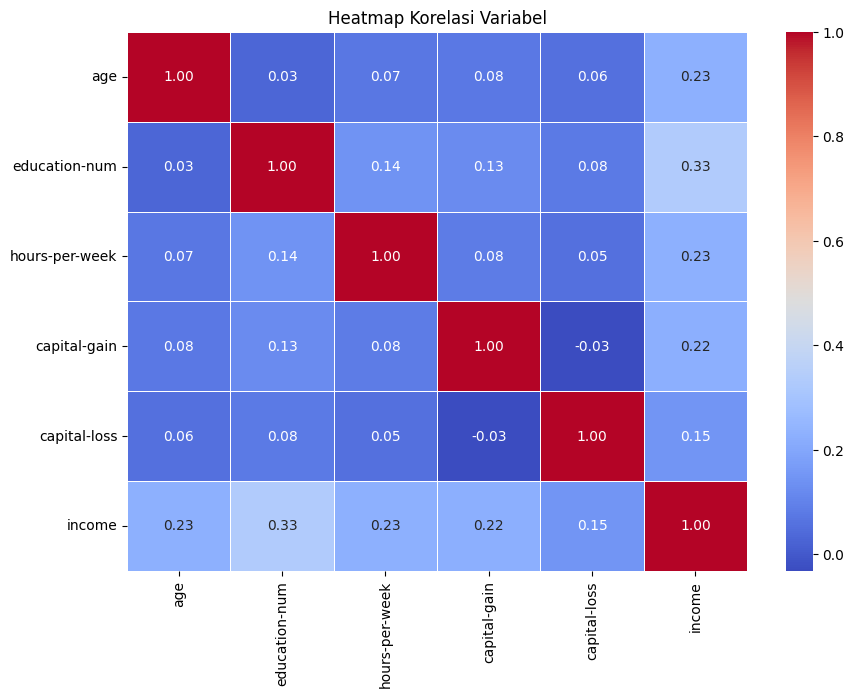

In [72]:
# Jawab Soal 1

# Variabel yang akan dianalisis
variabel = [
    'age',
    'education-num',
    'hours-per-week',
    'capital-gain',
    'capital-loss',
    'income'
]

# Membuat matriks korelasi
corr = df[variabel].corr()

# Menampilkan matriks korelasi
print("Matriks Korelasi:")
display(corr)

# Visualisasi korelasi menggunakan heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Heatmap Korelasi Variabel')
plt.show()

In [ ]:
# Hasil analisis jelaskan pada cell ini

In [ ]:
# Analisa

'''
Analisis korelasi digunakan untuk mengetahui hubungan linear antarvariabel.
Nilai korelasi berada pada rentang -1 sampai 1.

Korelasi positif menunjukkan bahwa ketika suatu variabel meningkat,
variabel lainnya cenderung ikut meningkat. Sebaliknya, korelasi negatif
menunjukkan kecenderungan hubungan yang berlawanan.

Berdasarkan correlation matrix, hubungan antara education-num dan
income dapat digunakan untuk melihat keterkaitan tingkat
pendidikan dengan kelompok pendapatan.

Age juga dapat dibandingkan dengan income untuk melihat apakah
terdapat hubungan antara usia dan pendapatan.

Capital-gain dan capital-loss perlu diperhatikan karena keduanya dapat
memiliki nilai korelasi tertentu dengan income_encoded, tetapi nilai
korelasi tidak berarti menunjukkan hubungan sebab-akibat.
Secara umum, semakin mendekati 1 atau -1 maka hubungan linear semakin kuat,
sedangkan nilai yang mendekati 0 menunjukkan hubungan linear yang lemah.

Berdasarkan hasil analisis korelasi, seluruh variabel yang dianalisis memiliki hubungan positif dengan variabel income, tetapi tingkat korelasinya relatif rendah.
Variabel education-num memiliki korelasi paling tinggi terhadap income, yaitu sebesar 0,33. Hal ini menunjukkan bahwa semakin tinggi tingkat pendidikan, terdapat kecenderungan income juga meningkat.
Variabel age dan hours-per-week memiliki nilai korelasi yang sama terhadap income, yaitu sebesar 0,23. Artinya, usia dan jumlah jam kerja per minggu memiliki hubungan positif yang relatif lemah dengan income.
Sementara itu, capital-gain memiliki korelasi sebesar 0,22 terhadap income, yang juga menunjukkan hubungan positif yang lemah.
Variabel capital-loss memiliki korelasi paling rendah terhadap income, yaitu sebesar 0,15.
Hal ini menunjukkan bahwa hubungan antara capital-loss dan income sangat lemah. Selain itu, capital-gain dan capital-loss memiliki korelasi sebesar -0,03, sehingga hubungan linear antara kedua variabel tersebut hampir tidak ada.
Secara keseluruhan, education-num merupakan variabel yang memiliki korelasi paling besar dengan income dibandingkan variabel lainnya dalam analisis ini.
Namun, nilai korelasi yang masih relatif rendah menunjukkan bahwa income tidak hanya berhubungan dengan satu variabel saja dan kemungkinan dipengaruhi oleh berbagai faktor lainnya.

'''

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [73]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


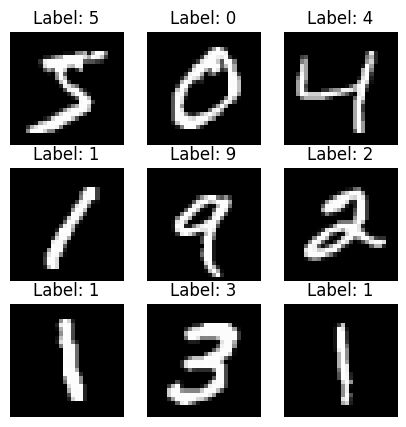

In [74]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

In [75]:
# Jawab Soal 1
import cv2
# Membuat array kosong untuk menyimpan hasil upsampling
X_test_upsampled = np.empty((X_test.shape[0], 32, 32), dtype=np.uint8)

# Upsampling seluruh data test
for i in range(X_test.shape[0]):
    X_test_upsampled[i] = cv2.resize(
        X_test[i],
        (32, 32),
        interpolation=cv2.INTER_LINEAR
    )

print("Shape sebelum upsampling :", X_test.shape)
print("Shape setelah upsampling :", X_test_upsampled.shape)

Shape sebelum upsampling : (10000, 28, 28)
Shape setelah upsampling : (10000, 32, 32)


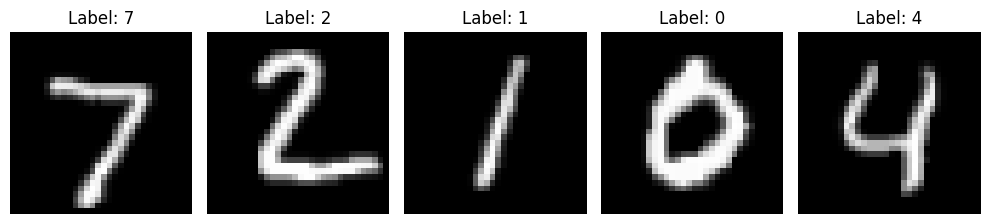

In [54]:
# Menampilkan 5 hasil upsampling

plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [76]:
# Jawab Soal 2

# Normalisasi nilai piksel dari 0-255 menjadi 0-1
X_test_normalized = X_test_upsampled.astype('float32') / 255.0

# Cek hasil
print("Shape:", X_test_normalized.shape)
print("Nilai minimum:", X_test_normalized.min())
print("Nilai maksimum:", X_test_normalized.max())

Shape: (10000, 32, 32)
Nilai minimum: 0.0
Nilai maksimum: 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [77]:
# Jawab Soal 3

# Membuat holder array kosong
X_test_flattened = np.empty(
    (X_test_normalized.shape[0], 32 * 32),
    dtype=np.float32
)

# Flatten seluruh data test
for i in range(X_test_normalized.shape[0]):
    X_test_flattened[i] = X_test_normalized[i].flatten()

print("Shape sebelum flatten :", X_test_normalized.shape)
print("Shape setelah flatten :", X_test_flattened.shape)

Shape sebelum flatten : (10000, 32, 32)
Shape setelah flatten : (10000, 1024)
